<a href="https://colab.research.google.com/github/abbyt3/JOUR410/blob/Final-Project---FIRST-DRAFT/Timm_JOUR410_FinalProject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Traffic Stops in Urbana, Illinois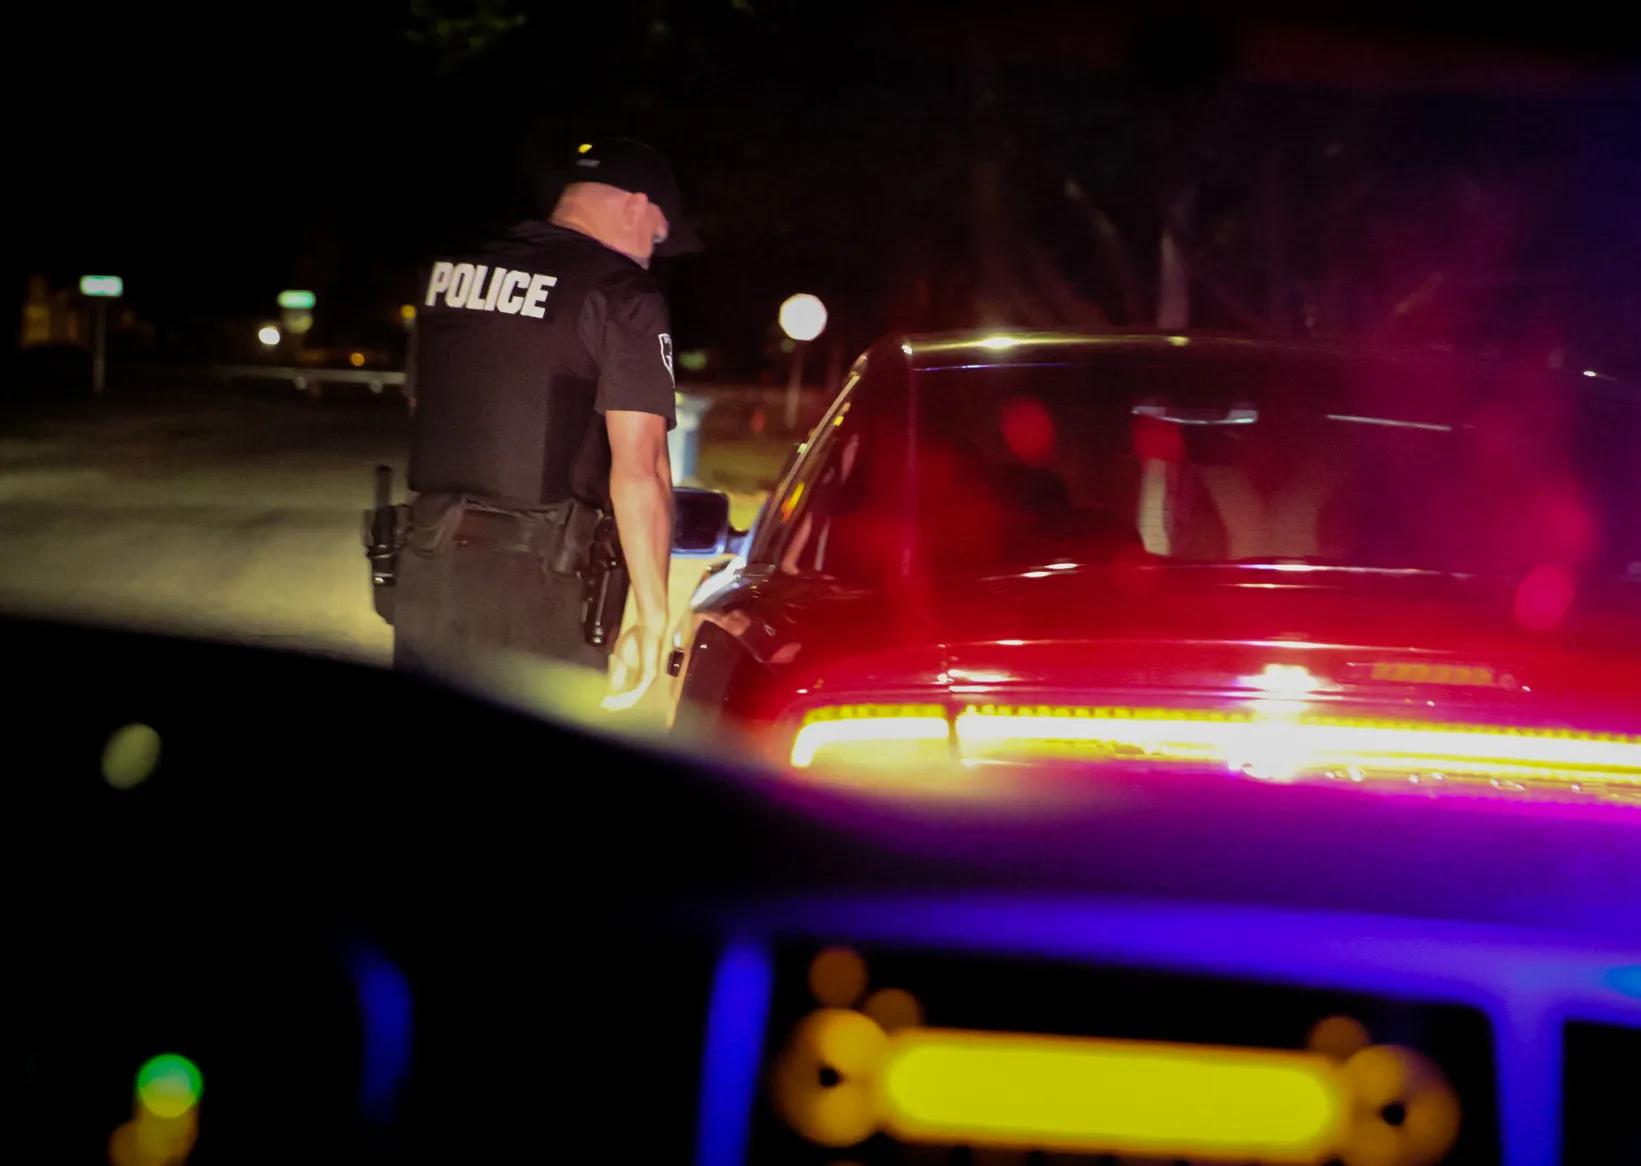

# Dataset Description

In this project, I examined a dataset regarding the traffic stops within Urbana from 2013 to 2023. There are fields about the individual's race, age, reason for the stop and the type of violation. I obtained this dataset through the Illinois government data website, data.illinois.gov. This particular dataset came from IDOT, or the Illinois Department of Transportation.

# Preview of Dataset

In [29]:
import pandas as pd
import matplotlib.pyplot as plt

In [35]:
from google.colab import files
Uploaded = files.upload('City_Of_Urbana__IDOT_Traffic_stop_Offense_Level_(Police_Data)_20251113.csv')

Saving City_Of_Urbana__IDOT_Traffic_stop_Offense_Level_(Police_Data)_20251113.csv to City_Of_Urbana__IDOT_Traffic_stop_Offense_Level_(Police_Data)_20251113.csv/City_Of_Urbana__IDOT_Traffic_stop_Offense_Level_(Police_Data)_20251113 (5).csv


In [182]:
df = pd.read_csv(list(uploaded.keys())[0])
pd.set_option('display.max_columns', None)
df

,DATE OF CONTACT,TIME OF CONTACT,INCIDENT NUMBER,STEP INDICATOR,GEO CODE,ANONYMOUS HOUSE NUMBER,ADDRESS STREET,CROSS STREET,MOTIVATION FOR STOP DESC,RACE DESCRIPTION,SEX DESCRIPTION,AGE AT CONTACT,RESIDENCY CODE,REASON FOR STOP,TYPE OF VIOLATION,CRIME CATEGORY,CRIME CATEGORY DESCRIPTION,CRIME CODE,CRIME DESCRIPTION,CRIME STATUS DESCRIPTION,VEHICLE YEAR,VEHICLE CONSENT SEARCH REQUESTED,VEHICLE CONSENT SEARCH GRANTED,PARAPHRENALIA FOUND VEHICLE CONSENT SEARCH,ALCOHOL FOUND VEHICLE CONSENT SEARCH,WEAPON FOUND VEHICLE CONSENT SEARCH,STOLEN PROPERTY FOUND VEHICLE CONSENT SEARCH,OTHER CONTRABAND FOUND VEHICLE CONSENT SEARCH,DRUG AMOUNT FOUND VEHICLE CONSENT SEARCH,CANINE SNIFF PERFORMED,CANINE ALERTED,CANINE SEARCH CONDUCTED,PARAPHRENALIA FOUND CANINE SEARCH,ALCOHOL FOUND CANINE SEARCH,WEAPON FOUND CANINE SEARCH,STOLEN PROPERTY FOUND CANINE SEARCH,OTHER CONTRABAND FOUND CANINE SEARCH,DRUG AMOUNT FOUND CANINE SEARCH,ANY CONTRABAND FOUND IN VEHICLE CONSENT OR CANINE SEARCH,CONSENT OR DOG SNIFF SEARCH CONDUCTED,MAPPING ADDRESS
0,2013 Jan 01 12:00:00 AM,02:50,UU1300001,NOT STEP,547-08,400.0,UNIVERSITY AV E,NaN,NaN,WHITE,FEMALE,30,Y,EQUIPMENT,NOT A MOVING VIOLATION,C28,Traffic Offenses,6630,DRIVING WITHOUT LIGHTS,TRAFFIC WARNING TICKET,2000,False,False,NOT APPLICABLE,NOT APPLICABLE,NOT APPLICABLE,NOT APPLICABLE,NOT APPLICABLE,NOT APPLICABLE,False,False,NOT APPLICABLE,NOT APPLICABLE,NOT APPLICABLE,NOT APPLICABLE,NOT APPLICABLE,NOT APPLICABLE,NaN,True,False,400 UNIVERSITY AV E
1,2013 Jan 01 12:00:00 AM,02:50,UU1300001,NOT STEP,547-08,400.0,UNIVERSITY AV E,NaN,NaN,WHITE,FEMALE,30,Y,EQUIPMENT,NOT A MOVING VIOLATION,C41,Assist Other Agency/Business,9081,ASSIST TOW TRUCK,ADMINISTRATIVELY CLOSED,2000,False,False,NOT APPLICABLE,NOT APPLICABLE,NOT APPLICABLE,NOT APPLICABLE,NOT APPLICABLE,NOT APPLICABLE,False,False,NOT APPLICABLE,NOT APPLICABLE,NOT APPLICABLE,NOT APPLICABLE,NOT APPLICABLE,NOT APPLICABLE,NaN,True,False,400 UNIVERSITY AV E
2,2013 Jan 01 12:00:00 AM,02:50,UU1300001,NOT STEP,547-08,400.0,UNIVERSITY AV E,NaN,NaN,WHITE,FEMALE,30,Y,EQUIPMENT,NOT A MOVING VIOLATION,C28,Traffic Offenses,2461,OPERATE UNINSURED MOTOR VEHICLE,CLEARED BY ADULT ARREST,2000,False,False,NOT APPLICABLE,NOT APPLICABLE,NOT APPLICABLE,NOT APPLICABLE,NOT APPLICABLE,NOT APPLICABLE,False,False,NOT APPLICABLE,NOT APPLICABLE,NOT APPLICABLE,NOT APPLICABLE,NOT APPLICABLE,NOT APPLICABLE,NaN,True,False,400 UNIVERSITY AV E
3,2013 Jan 01 12:00:00 AM,02:50,UU1300001,NOT STEP,547-08,400.0,UNIVERSITY AV E,NaN,NaN,WHITE,FEMALE,30,Y,EQUIPMENT,NOT A MOVING VIOLATION,C28,Traffic Offenses,6608,IMPROPER LANE USAGE,CLEARED BY ADULT ARREST,2000,False,False,NOT APPLICABLE,NOT APPLICABLE,NOT APPLICABLE,NOT APPLICABLE,NOT APPLICABLE,NOT APPLICABLE,False,False,NOT APPLICABLE,NOT APPLICABLE,NOT APPLICABLE,NOT APPLICABLE,NOT APPLICABLE,NOT APPLICABLE,NaN,True,False,400 UNIVERSITY AV E
4,2013 Jan 01 12:00:00 AM,02:50,UU1300001,NOT STEP,547-08,400.0,UNIVERSITY AV E,NaN,NaN,WHITE,FEMALE,30,Y,EQUIPMENT,NOT A MOVING VIOLATION,C28,Traffic Offenses,2470,NO VALID DL DRIVERS LICENSE,CLEARED BY ADULT ARREST,2000,False,False,NOT APPLICABLE,NOT APPLICABLE,NOT APPLICABLE,NOT APPLICABLE,NOT APPLICABLE,NOT APPLICABLE,False,False,NOT APPLICABLE,NOT APPLICABLE,NOT APPLICABLE,NOT APPLICABLE,NOT APPLICABLE,NOT APPLICABLE,NaN,True,False,400 UNIVERSITY AV E
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
36312,2020 Sep 09 12:00:00 AM,20:28,UW2000552,NOT STEP,605-16,1.0,MCHENRY ST,PHILO RD,TRAFFIC ISSUE,HISPANIC,MALE,NaN,N,MOVING VIOLATION,TRAFFIC SIGN OR SIGNAL,C28,Traffic Offenses,6605,TRAFFIC SIGN VIOLATION,TRAFFIC WARNING TICKET,2005,False,False,NOT APPLICABLE,NOT APPLICABLE,NOT APPLICABLE,NOT APPLICABLE,NOT APPLICABLE,NOT APPLICABLE,False,False,NOT APPLICABLE,NOT APPLICABLE,NOT APPLICABLE,NOT APPLICABLE,NOT APPLICABLE,NOT APPLICABLE,NaN,True,False,1 MCHENRY ST
36313,2022 Sep 09 12:00:00 AM,23:

# Are there racial disparities in Urbana residents who are pulled over for traffic stops?

I wanted to look at the potential racial disparity in those who are pulled over by the Urbana police department. According to the Bureau of Justice Statistics, data showed that taffic stops continued to be the most common reason police-initiated contact for all races, but Black people were stopped at higher rates than other races.

While this data set doesn't focus on the race of individuals pulled over in Urbana, it does offer a cohesive look into any possible disparity between the years 2013 to 2023.

First, I want to look at these disparities by year. Particularly, the year 2022, since it was the last full year included in the data set. Then, I'd like to look at the overall potential disparity among traffic stops in Urbana between 2013 to 2023.

In [199]:
df['DATE OF CONTACT'] = pd.to_datetime(df['DATE OF CONTACT'])
df['year'] = df['DATE OF CONTACT'].dt.year

/tmp/ipython-input-4261638752.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['DATE OF CONTACT'] = pd.to_datetime(df['DATE OF CONTACT'])


In [200]:
df_year = df[df['year'] == 2022]

In [80]:
race_2022_table = df_year.groupby('RACE DESCRIPTION').size().reset_index(name='count')
race_2022_table

,RACE DESCRIPTION,count
0,AMERICAN INDIAN/ALASKAN,3
1,ASIAN,95
2,BLACK,1025
3,HISPANIC,147
4,WHITE,635


In [119]:
race_2022_table['race_short'] = race_2022_table['RACE DESCRIPTION'].replace({
    'AMERICAN INDIAN/ALASKAN': 'AI/AN'
})

In [134]:
race_summary_table = df.groupby('RACE DESCRIPTION').size().reset_index(name='count')
race_summary_table

,RACE DESCRIPTION,count
0,AMERICAN INDIAN/ALASKAN,80
1,ASIAN,3212
2,BLACK,12903
3,HISPANIC,2130
4,UNKNOWN,2
5,WHITE,17990


In [136]:
race_summary_table['race_short'] = race_summary_table['RACE DESCRIPTION'].replace({
    'AMERICAN INDIAN/ALASKAN': 'AI/AN'
})

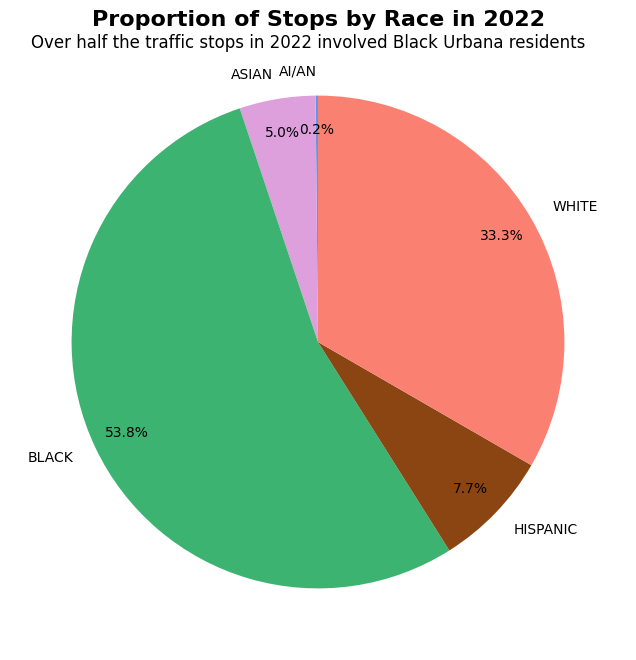

In [138]:
plt.figure(figsize=(8,8))

colors=['cornflowerblue', 'plum', 'mediumseagreen', 'saddlebrown', 'salmon']

plt.pie(
    race_2022_table['count'],
    labels=race_2022_table['race_short'],
    autopct='%1.1f%%',
    pctdistance=0.86,
    startangle=90,
    colors=colors
)

plt.title('Proportion of Stops by Race in 2022', fontweight = 'semibold', fontsize=16)
plt.suptitle("Over half the traffic stops in 2022 involved Black Urbana residents", fontsize=12, y=0.88)
plt.show()

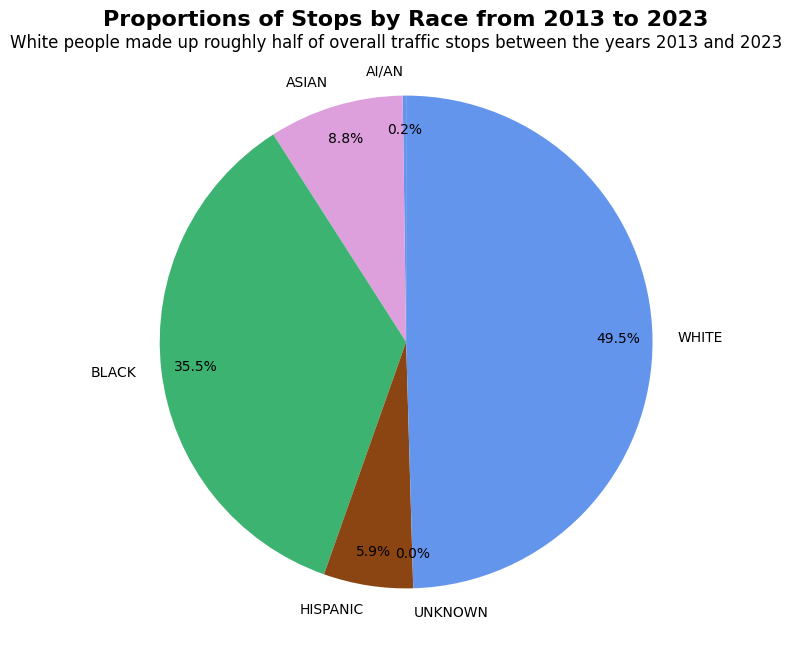

In [137]:
plt.figure(figsize=(8,8))

colors=['cornflowerblue', 'plum', 'mediumseagreen', 'saddlebrown', 'salmon']

plt.pie(
    race_summary_table['count'],
    labels=race_summary_table['race_short'],
    autopct='%1.1f%%',
    pctdistance=0.86,
    startangle=90,
    colors=colors
)

plt.title('Proportions of Stops by Race from 2013 to 2023', fontweight = 'semibold', fontsize=16)
plt.suptitle('White people made up roughly half of overall traffic stops between the years 2013 and 2023', fontsize=12, y=0.88)
plt.show()

**Conclusion and Interpretation:**

The overall data of Urbana traffic stops, naturally, does not account for different trends that occur year-by-year. Not only were Black people stopped the most in 2022, but even in the incomplete data from 2023 showed that Black people were pulled over at a higher rate than any other race, despite the data from that year ending in mid-February.

...sociologist prof interviewee information here, along with transitions... something about recent trends, why we're seeing a shift in who's being pulled over, etc.

# What is the most common crime status for each race in 2022?

Previous research from the Bureau of Justice Statistics suggest that Black drivers are more than twice as likely as white drivers to be searched or arrested during a traffic stop. With 2022 in mind specifically, BJS data from 2022 shows that 9% of Black drivers were searched or arrested during a traffic stop, compared to 3% of white drivers.

For this question, I created a new pivot table for the year 2022 including the race of individuals stopped, as well as their crime status following the traffic stop.

In [201]:
df_2022 = df[df['year'] == 2022]

pivot = pd.pivot_table(df_2022, index='RACE DESCRIPTION', columns='CRIME STATUS DESCRIPTION', aggfunc='size', fill_value=0)
pivot

CRIME STATUS DESCRIPTION,ADMINISTRATIVELY CLOSED,"CHARGED BY SAO, NO ARREST",CLEARED BY ADULT ARREST,CLEARED BY JUVENILE ARREST,PENDING,REFERRED TO OTHER JURISDICTION,TRAFFIC WARNING TICKET
RACE DESCRIPTION,,,,,,,
AMERICAN INDIAN/ALASKAN,0,0,0,0,0,0,3
ASIAN,0,0,50,0,0,0,45
BLACK,76,2,574,6,8,5,354
HISPANIC,8,0,84,2,0,0,53
WHITE,15,0,320,1,0,0,299


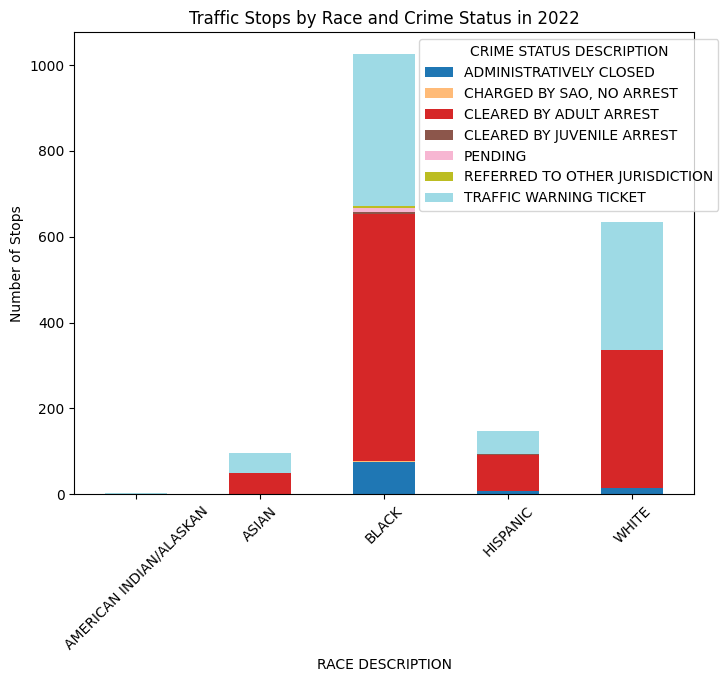

In [141]:
pivot.plot(kind='bar', stacked=True, figsize=(8,6), colormap='tab20')
plt.ylabel('Number of Stops')
plt.title('Traffic Stops by Race and Crime Status in 2022')
plt.xticks(rotation=45)
plt.legend(title='CRIME STATUS DESCRIPTION', bbox_to_anchor=(1.05, 1))
plt.show()

**Conclusion and Interpretation:**

Because Black people were already pulled over at a disproportionate rate in 2022, despite making up less than 20% of the overall Urbana population — compared to white population, which makes up roughly half of the Urbana population — we would expect to see a higher rate of traffic tickets. However, of the 1,028 "cleared by adult arrest" crime statuses, Black people made up 56% of those adult arrests.

Interestingly, of the 99 total "administratively closed" statuses, Black people represented 77% of that status in 2022. "Administratively closed" means a case has been temporarily paused and removed from the active court calendar; however, it is not permanently dismissed or decided. For traffic stops in particular, this status usually indicates further action is on hold due to a specific issue that needs to be resolved outside of immediate court proceedings.

...interviewee responses here? maybe...

# What percent of people involved in traffic stops are college aged?

Due to the proximity to the University of Illinois Urbana-Champaign, including streets surrounding the campus home to students at the University, I wanted to look at any potential trends among age in traffic stops.

First, I'd like to look at the overall age proportion, then I want to revist the year 2022 to see if there's been a new change, or trend, in the proportion of age groups involved in traffic stops.

However, because "college aged" is based on an individual's own academic career, and because the University offers graduate programs, it is important to note that there are limitations to this question. For this question, I will include ages from 18 to 35, since 35 is often cited as the average age of a graduate student.

In [191]:
df['AGE AT CONTACT'] = pd.to_numeric(df['AGE AT CONTACT'], errors='coerce')

In [192]:
bins = [0, 18, 25, 35, 45, 60, 100]
labels = ['<18', '18-25', '26-35', '36-45', '46-60', '60+']
df['age_group'] = pd.cut(df['AGE AT CONTACT'], bins=bins, labels=labels)

age_group_counts = df.groupby('age_group').size().reset_index(name='count')
age_group_counts

/tmp/ipython-input-1647530596.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_group_counts = df.groupby('age_group').size().reset_index(name='count')


,age_group,count
0,<18,1424
1,18-25,10289
2,26-35,8575
3,36-45,4799
4,46-60,4721
5,60+,2143


In [208]:
year3 = 2022
df_year = df[df['year'] == year3]

df_year['age_group'] = pd.cut(df_year['AGE AT CONTACT'], bins=bins, labels=labels)

age_counts_2022 = df_year.groupby('age_group').size().reset_index(name='count')

age_counts_2022

/tmp/ipython-input-2376482071.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_year['age_group'] = pd.cut(df_year['AGE AT CONTACT'], bins=bins, labels=labels)
/tmp/ipython-input-2376482071.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_counts_2022 = df_year.groupby('age_group').size().reset_index(name='count')


,age_group,count
0,<18,89
1,18-25,647
2,26-35,557
3,36-45,293
4,46-60,217
5,60+,102


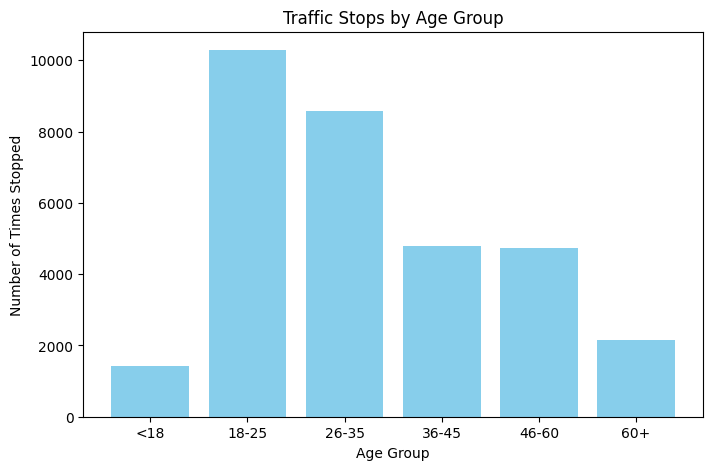

In [212]:
plt.figure(figsize=(8,5))
plt.bar(age_group_counts['age_group'], age_group_counts['count'], color='skyblue')
plt.xlabel('Age Group')
plt.ylabel('Number of Times Stopped')
plt.title('Traffic Stops by Age Group')
plt.show()

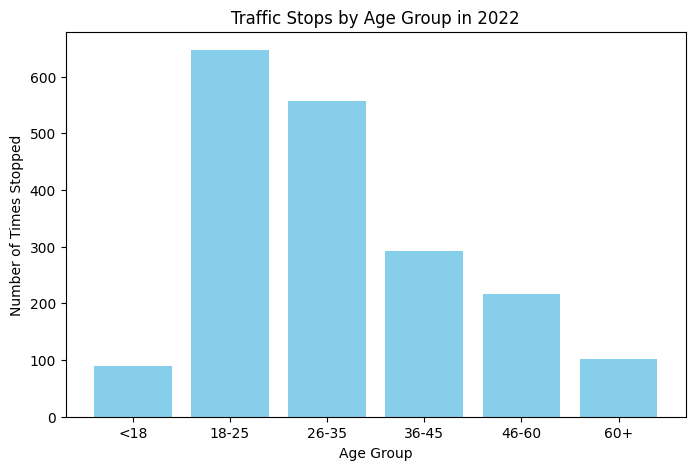

In [213]:
plt.figure(figsize=(8,5))
plt.bar(age_counts_2022['age_group'], age_counts_2022['count'], color='skyblue')
plt.xlabel('Age Group')
plt.ylabel('Number of Times Stopped')
plt.title('Traffic Stops by Age Group in 2022')
plt.show()

**Conclusion and Interpretation:**

The overall trend of people pulled over by age group holds relatively true to the recent data within this data set. There is a slight decrease in the 26-35 age group in 2022 than the overall trend, as well as the 40-60 age group and 60+ age group.

While some age groups have slightly decreased compared to the overall trend between 2013 to 2023, Urbana's proximity to the University, which has a current enrollment rate of 60,000, has seen the most traffic stops among the 18-25 and 26-35 age groups.

...insert quotes and transitions from police officer...build stronger conclusion.